In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("../data/customers_cleaned.csv")
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")
applications = pd.read_csv(
    "../data/applications_cleaned.csv",
    low_memory=False
)

In [3]:
customers = pd.read_csv("../data/customers_cleaned.csv")
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")
applications = pd.read_csv(
    "../data/applications_cleaned.csv",
    low_memory=False
)

In [5]:
loan_default_flag = loans.merge(
    defaults[['Loan_ID']],
    on='Loan_ID',
    how='left',
    indicator=True
)

loan_default_flag['Default_Flag'] = (
    loan_default_flag['_merge'] == 'both'
).astype(int)

loan_default_flag = loan_default_flag[['Customer_ID', 'Default_Flag']]

In [6]:
customer_behavior = loan_default_flag.groupby('Customer_ID').agg(
    Total_Loans=('Default_Flag', 'count'),
    Default_Count=('Default_Flag', 'sum')
).reset_index()

In [7]:
def repayment_category(row):
    if row['Default_Count'] == 0:
        return 'Always On Time'
    elif row['Default_Count'] == 1:
        return 'Occasional Defaulter'
    else:
        return 'Frequent Defaulter'

customer_behavior['Repayment_Behavior'] = customer_behavior.apply(
    repayment_category, axis=1
)

In [8]:
customer_behavior = customer_behavior.merge(
    customers,
    on='Customer_ID',
    how='left'
)

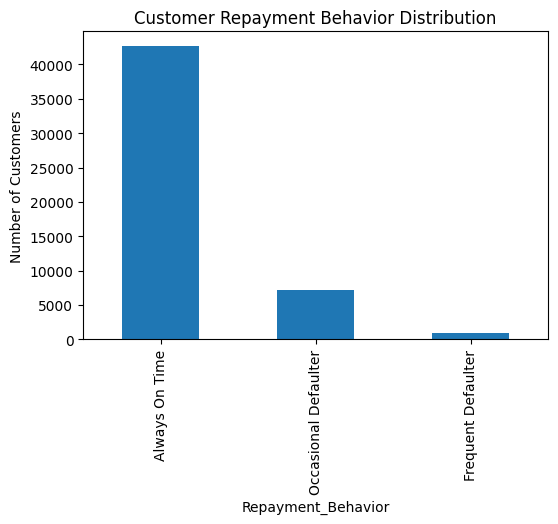

In [9]:
behavior_dist = customer_behavior['Repayment_Behavior'].value_counts()

behavior_dist.plot(kind='bar', figsize=(6,4))
plt.title("Customer Repayment Behavior Distribution")
plt.ylabel("Number of Customers")
plt.show()

In [10]:
high_value_customers = customer_behavior[
    (customer_behavior['Repayment_Behavior'] == 'Always On Time') &
    (customer_behavior['Credit_Score'] >= 700)
]

In [11]:
high_value_customers.shape

(11604, 17)

In [12]:
apps_with_customers = applications.merge(
    customers[['Customer_ID', 'Employment_Status']],
    on='Customer_ID',
    how='left'
)

employment_approval = apps_with_customers.groupby(
    ['Employment_Status', 'Approval_Status']
).size().unstack(fill_value=0)

employment_approval

Approval_Status,Approved,Rejected
Employment_Status,,
Salaried,23452,4130
Self-Employed,23346,4146
Unemployed,23202,4324


### Task 17 – Customer Behavior Insights

- Majority of customers exhibit consistent on-time repayment behavior
- Frequent defaulters represent a smaller but high-risk segment
- High-value customers combine strong credit scores with clean repayment history
- Employment status influences application approval outcomes
- Targeted retention strategies can maximize lifetime value of high-quality customers